# Analysis Zone

Objetivo de la fase:

1. Usar `exploitation_zone.duckdb` como fuente de datos para el análisis.
2. Estudiar la dinámica de ocupación de Airbnb en las distintas zonas de Barcelona a través de la variable `booked_rate`.
3. Analizar factores clave que pueden influir en la ocupación, como:
   - la estacionalidad
   - el efecto fin de semana
   - la relación entre precio y ocupación
   - el nivel de atractivo turístico de cada zona
4. Identificar patrones temporales de comportamiento entre zonas.
5. Construir y comparar modelos de predicción del `booked_rate` utilizando distintos conjuntos de variables:
   - calendario
   - calendario + clima
   - calendario + precio
   - calendario + clima + precio + turismo
6. Evaluar los modelos mediante un split temporal por fecha.



In [7]:
import math
from collections import defaultdict
from datetime import datetime
from pathlib import Path
from typing import Iterable

import duckdb
import matplotlib.pyplot as plt

ROOT = Path.cwd()

def resolve_exploitation_db() -> Path:
    candidates = [
        ROOT / "exploitation_zone" / "exploitation_zone.duckdb",
        ROOT / "exploitation_zone.duckdb",
        Path("/mnt/data/exploitation_zone/exploitation_zone.duckdb"),
        Path("/mnt/data/exploitation_zone.duckdb"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]

EXPLOITATION_DB = resolve_exploitation_db()

def ensure_phase_dirs() -> None:
    pass


In [8]:
def read_duckdb_rows(db_path: Path, table_name: str, order_by: str | None = None) -> list[dict[str, object]]:
    if duckdb is None:
        raise RuntimeError("DuckDB no está instalado en este entorno.")
    if not db_path.exists():
        raise FileNotFoundError(f"No se encontró la base de datos: {db_path}")
    conn = duckdb.connect(str(db_path), read_only=True)
    try:
        query = f'SELECT * FROM "{table_name}"'
        if order_by:
            query += f" ORDER BY {order_by}"
        cursor = conn.execute(query)
        columns = [description[0] for description in cursor.description]
        return [dict(zip(columns, row)) for row in cursor.fetchall()]
    finally:
        conn.close()

def mean(values: list[float]) -> float:
    return sum(values) / len(values) if values else 0.0

def median(values: list[float]) -> float:
    if not values:
        return 0.0
    ordered = sorted(values)
    mid = len(ordered) // 2
    if len(ordered) % 2 == 1:
        return ordered[mid]
    return (ordered[mid - 1] + ordered[mid]) / 2

def quantile(values: list[float], q: float) -> float:
    if not values:
        return 0.0
    ordered = sorted(values)
    if len(ordered) == 1:
        return ordered[0]
    position = (len(ordered) - 1) * q
    lower = int(math.floor(position))
    upper = int(math.ceil(position))
    if lower == upper:
        return ordered[lower]
    fraction = position - lower
    return ordered[lower] * (1 - fraction) + ordered[upper] * fraction

def pearson_correlation(x_values: list[float], y_values: list[float]) -> float:
    if not x_values or not y_values or len(x_values) != len(y_values):
        return 0.0
    x_mean = mean(x_values)
    y_mean = mean(y_values)
    numerator = sum((x - x_mean) * (y - y_mean) for x, y in zip(x_values, y_values))
    x_den = math.sqrt(sum((x - x_mean) ** 2 for x in x_values))
    y_den = math.sqrt(sum((y - y_mean) ** 2 for y in y_values))
    denominator = x_den * y_den
    return 0.0 if denominator == 0 else numerator / denominator

def euclidean_distance(a: list[float], b: list[float]) -> float:
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

def standardize_matrix(matrix: list[list[float]]) -> tuple[list[list[float]], list[float], list[float]]:
    if not matrix:
        return [], [], []
    columns = list(zip(*matrix))
    means = [mean(list(col)) for col in columns]
    stds = []
    for idx, col in enumerate(columns):
        variance = mean([(value - means[idx]) ** 2 for value in col])
        stds.append(math.sqrt(variance) if variance > 0 else 1.0)
    scaled = []
    for row in matrix:
        scaled.append([(value - means[idx]) / stds[idx] for idx, value in enumerate(row)])
    return scaled, means, stds

def run_kmeans(matrix: list[list[float]], k: int = 4, max_iter: int = 40) -> tuple[list[int], list[list[float]], float]:
    if not matrix:
        return [], [], 0.0
    k = max(1, min(k, len(matrix)))
    seed_indexes = sorted({int(i * len(matrix) / k) for i in range(k)})
    centroids = [matrix[idx][:] for idx in seed_indexes]
    labels = [0] * len(matrix)
    for _ in range(max_iter):
        new_labels = []
        for row in matrix:
            distances = [euclidean_distance(row, centroid) for centroid in centroids]
            new_labels.append(min(range(len(distances)), key=distances.__getitem__))
        if new_labels == labels:
            break
        labels = new_labels
        for cluster_id in range(len(centroids)):
            cluster_rows = [row for row, label in zip(matrix, labels) if label == cluster_id]
            if not cluster_rows:
                continue
            centroids[cluster_id] = [
                mean([row[col_idx] for row in cluster_rows])
                for col_idx in range(len(cluster_rows[0]))
            ]
    inertia = 0.0
    for row, label in zip(matrix, labels):
        inertia += euclidean_distance(row, centroids[label]) ** 2
    return labels, centroids, round(inertia, 6)

def mae(y_true: list[float], y_pred: list[float]) -> float:
    return mean([abs(y - y_hat) for y, y_hat in zip(y_true, y_pred)])

def rmse(y_true: list[float], y_pred: list[float]) -> float:
    return math.sqrt(mean([(y - y_hat) ** 2 for y, y_hat in zip(y_true, y_pred)]))

def r2_score(y_true: list[float], y_pred: list[float]) -> float:
    y_mean = mean(y_true)
    ss_tot = sum((y - y_mean) ** 2 for y in y_true)
    ss_res = sum((y - y_hat) ** 2 for y, y_hat in zip(y_true, y_pred))
    return 0.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)

def dot_product(a: list[float], b: list[float]) -> float:
    return sum(x * y for x, y in zip(a, b))

def train_linear_regression_gradient_descent(
    x_train: list[list[float]],
    y_train: list[float],
    learning_rate: float = 0.03,
    epochs: int = 1200,
) -> list[float]:
    if not x_train:
        return []
    weights = [0.0] * (len(x_train[0]) + 1)
    sample_count = len(x_train)
    for _ in range(epochs):
        gradients = [0.0] * len(weights)
        for row, target in zip(x_train, y_train):
            prediction = weights[0] + dot_product(weights[1:], row)
            error = prediction - target
            gradients[0] += error
            for idx, value in enumerate(row, start=1):
                gradients[idx] += error * value
        for idx in range(len(weights)):
            weights[idx] -= learning_rate * (gradients[idx] / sample_count)
    return weights

def predict_linear_regression(weights: list[float], x_rows: list[list[float]]) -> list[float]:
    if not weights:
        return []
    return [weights[0] + dot_product(weights[1:], row) for row in x_rows]

def knn_predict(
    x_train: list[list[float]],
    y_train: list[float],
    x_test: list[list[float]],
    k: int = 7,
) -> list[float]:
    if not x_train or not x_test:
        return []
    effective_k = max(1, min(k, len(x_train)))
    predictions = []
    for row in x_test:
        distances = [(euclidean_distance(row, train_row), target) for train_row, target in zip(x_train, y_train)]
        neighbors = sorted(distances, key=lambda item: item[0])[:effective_k]
        predictions.append(mean([target for _, target in neighbors]))
    return predictions

def month_to_season(month: int) -> str:
    mapping = {
        12: "winter", 1: "winter", 2: "winter",
        3: "spring", 4: "spring", 5: "spring",
        6: "summer", 7: "summer", 8: "summer",
        9: "autumn", 10: "autumn", 11: "autumn",
    }
    return mapping[month]

def add_calendar_features(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    enriched = []
    for row in rows:
        date_value = datetime.fromisoformat(str(row["date"]))
        enriched_row = dict(row)
        enriched_row["month"] = date_value.month
        enriched_row["day_of_week"] = date_value.weekday()
        enriched_row["is_weekend"] = 1 if date_value.weekday() >= 5 else 0
        enriched_row["season"] = month_to_season(date_value.month)
        enriched.append(enriched_row)
    return enriched

def assign_tourism_tier(rows: list[dict[str, object]], score_key: str = "neighborhood_tourism_asset_score") -> list[dict[str, object]]:
    scores = [float(row[score_key]) for row in rows]
    q1 = quantile(scores, 1 / 3)
    q2 = quantile(scores, 2 / 3)
    enriched = []
    for row in rows:
        score = float(row[score_key])
        tier = "low"
        if score > q2:
            tier = "high"
        elif score > q1:
            tier = "medium"
        enriched_row = dict(row)
        enriched_row["tourism_tier"] = tier
        enriched.append(enriched_row)
    return enriched

def temporal_train_test_split(rows: list[dict[str, object]], holdout_ratio: float = 0.2) -> tuple[list[dict[str, object]], list[dict[str, object]], str]:
    unique_dates = sorted({str(row["date"]) for row in rows})
    if len(unique_dates) <= 1:
        return rows, rows, unique_dates[0] if unique_dates else ""
    split_idx = max(1, int(len(unique_dates) * (1 - holdout_ratio)))
    cutoff_date = unique_dates[split_idx - 1]
    train_rows = [row for row in rows if str(row["date"]) <= cutoff_date]
    test_rows = [row for row in rows if str(row["date"]) > cutoff_date]
    if not test_rows:
        train_rows = rows[:-1] or rows
        test_rows = rows[-1:]
        cutoff_date = str(train_rows[-1]["date"])
    return train_rows, test_rows, cutoff_date

def save_plot(title: str, x_values: list[object], y_values: list[float], kind: str = "bar") -> str:
    plt.figure(figsize=(10, 5))
    if kind == "line":
        plt.plot(x_values, y_values, marker="o", linewidth=1.5)
    elif kind == "scatter":
        plt.scatter(x_values, y_values, alpha=0.6)
    else:
        plt.bar(x_values, y_values)
        plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return title


In [9]:
def run_exploratory_pipeline() -> dict[str, object]:
    zone_rows = [row for row in read_duckdb_rows(EXPLOITATION_DB, "airbnb_zone_features") if row["listing_count"] >= 15]
    zone_day_rows = add_calendar_features(
        [row for row in read_duckdb_rows(EXPLOITATION_DB, "airbnb_zone_day_features", order_by="date, district_name, neighborhood_name") if row["listing_count"] >= 15]
    )
    zone_day_rows = assign_tourism_tier(zone_day_rows)

    by_month: dict[int, list[float]] = defaultdict(list)
    by_weekend: dict[str, list[float]] = defaultdict(list)
    by_season: dict[str, list[float]] = defaultdict(list)
    tourism_group_stats: dict[str, list[dict[str, object]]] = defaultdict(list)

    for row in zone_day_rows:
        booked_rate = float(row["booked_rate"])
        by_month[int(row["month"])].append(booked_rate)
        by_weekend["weekend" if int(row["is_weekend"]) == 1 else "weekday"].append(booked_rate)
        by_season[str(row["season"])].append(booked_rate)
        tourism_group_stats[str(row["tourism_tier"])].append(row)

    month_summary = [
        {"month": month, "avg_booked_rate": round(mean(values), 4), "median_booked_rate": round(median(values), 4), "observations": len(values)}
        for month, values in sorted(by_month.items())
    ]
    weekend_summary = [
        {"day_group": group, "avg_booked_rate": round(mean(values), 4), "observations": len(values)}
        for group, values in sorted(by_weekend.items())
    ]
    season_summary = [
        {"season": season, "avg_booked_rate": round(mean(values), 4), "observations": len(values)}
        for season, values in sorted(by_season.items())
    ]
    tourism_summary = []
    for tier in ["low", "medium", "high"]:
        tier_rows = tourism_group_stats[tier]
        if not tier_rows:
            continue
        tourism_summary.append(
            {
                "tourism_tier": tier,
                "avg_booked_rate": round(mean([float(row["booked_rate"]) for row in tier_rows]), 4),
                "avg_calendar_price": round(mean([float(row["avg_calendar_price"]) for row in tier_rows]), 4),
                "avg_temperature": round(mean([float(row["temperature_avg"]) for row in tier_rows]), 4),
                "observations": len(tier_rows),
            }
        )

    overall_price_vs_booked_corr = round(
        pearson_correlation(
            [float(row["avg_calendar_price"]) for row in zone_day_rows],
            [float(row["booked_rate"]) for row in zone_day_rows],
        ),
        6,
    )
    correlation_by_tourism_tier = []
    for tier in ["low", "medium", "high"]:
        tier_rows = tourism_group_stats[tier]
        if not tier_rows:
            continue
        correlation_by_tourism_tier.append(
            {
                "tourism_tier": tier,
                "price_vs_booked_rate_correlation": round(
                    pearson_correlation(
                        [float(row["avg_calendar_price"]) for row in tier_rows],
                        [float(row["booked_rate"]) for row in tier_rows],
                    ),
                    6,
                ),
            }
        )

    top_price_zones = sorted(zone_rows, key=lambda row: float(row["avg_price"]), reverse=True)[:10]
    visuals = [
        save_plot(
            "Precio medio Airbnb por zona",
            [f"{row['district_name']} / {row['neighborhood_name']}" for row in top_price_zones],
            [float(row["avg_price"]) for row in top_price_zones],
        ),
        save_plot(
            "Booked rate medio por mes",
            [row["month"] for row in month_summary],
            [row["avg_booked_rate"] for row in month_summary],
            kind="line",
        ),
        save_plot(
            "Booked rate: fin de semana vs entre semana",
            [row["day_group"] for row in weekend_summary],
            [row["avg_booked_rate"] for row in weekend_summary],
        ),
        save_plot(
            "Booked rate medio por temporada",
            [row["season"] for row in season_summary],
            [row["avg_booked_rate"] for row in season_summary],
        ),
        save_plot(
            "Precio medio vs booked rate",
            [float(row["avg_calendar_price"]) for row in zone_day_rows],
            [float(row["booked_rate"]) for row in zone_day_rows],
            kind="scatter",
        ),
    ]
    return {
        "source_tables": ["airbnb_zone_features", "airbnb_zone_day_features"],
        "top_price_zones": [
            {
                "district_name": row["district_name"],
                "neighborhood_name": row["neighborhood_name"],
                "listing_count": row["listing_count"],
                "avg_price": row["avg_price"],
                "neighborhood_tourism_asset_score": row["neighborhood_tourism_asset_score"],
            }
            for row in top_price_zones
        ],
        "booked_rate_by_month": month_summary,
        "booked_rate_by_day_group": weekend_summary,
        "booked_rate_by_season": season_summary,
        "tourism_tier_summary": tourism_summary,
        "overall_price_vs_booked_rate_correlation": overall_price_vs_booked_corr,
        "price_vs_booked_rate_correlation_by_tourism_tier": correlation_by_tourism_tier,
        "visualizations": visuals,
    }


In [10]:
def month_name_short(month: int) -> str:
    month_names = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
    }
    return month_names.get(month, str(month))

def cluster_centroid_distances(matrix: list[list[float]], labels: list[int], centroids: list[list[float]]) -> list[float]:
    distances = []
    for row, label in zip(matrix, labels):
        distances.append(euclidean_distance(row, centroids[label]))
    return distances

def plot_cluster_monthly_profiles(cluster_summary: list[dict[str, object]]) -> str:
    plt.figure(figsize=(10, 5))
    x_values = list(range(1, 13))
    for summary in cluster_summary:
        plt.plot(
            x_values,
            [float(value) for value in summary["monthly_profile"]],
            marker="o",
            linewidth=1.8,
            label=f"Cluster {summary['cluster_id']}",
        )
    plt.xticks(x_values, [month_name_short(month) for month in x_values])
    plt.title("Perfil mensual medio del booked rate por cluster")
    plt.xlabel("Mes")
    plt.ylabel("Booked rate medio")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return "Perfil mensual medio del booked rate por cluster"

def plot_neighborhoods_by_cluster(enriched_rows: list[dict[str, object]]) -> list[str]:
    visual_titles = []
    cluster_ids = sorted({int(row["cluster_id"]) for row in enriched_rows})

    for cluster_id in cluster_ids:
        cluster_rows = [row for row in enriched_rows if int(row["cluster_id"]) == cluster_id]

        labels = [
            f"{row['district_name']} / {row['neighborhood_name']}"
            for row in cluster_rows
        ]
        values = [
            mean([float(row[f"booked_rate_month_{month:02d}"]) for month in range(1, 13)])
            for row in cluster_rows
        ]

        pairs = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
        labels_sorted = [p[0] for p in pairs]
        values_sorted = [p[1] for p in pairs]

        plt.figure(figsize=(10, max(4, len(labels_sorted) * 0.35)))
        plt.barh(labels_sorted, values_sorted)
        plt.gca().invert_yaxis()
        plt.title(f"Barrios del cluster {cluster_id}")
        plt.xlabel("Booked rate medio anual")
        plt.ylabel("Zona")
        plt.tight_layout()
        plt.show()

        visual_titles.append(f"Barrios del cluster {cluster_id}")

    return visual_titles

def describe_temporal_clusters(
    zone_rows: list[dict[str, object]],
    labels: list[int],
    scaled_matrix: list[list[float]],
    centroids: list[list[float]],
) -> list[dict[str, object]]:
    grouped_rows: dict[int, list[dict[str, object]]] = defaultdict(list)
    grouped_scaled_rows: dict[int, list[list[float]]] = defaultdict(list)

    for row, label, scaled_row in zip(zone_rows, labels, scaled_matrix):
        grouped_rows[label].append(row)
        grouped_scaled_rows[label].append(scaled_row)

    global_avg_booked_rate = mean(
        [
            mean([float(row[f"booked_rate_month_{month:02d}"]) for month in range(1, 13)])
            for row in zone_rows
        ]
    )
    global_avg_price = mean([float(row["avg_price"]) for row in zone_rows])
    global_avg_tourism = mean([float(row["neighborhood_tourism_asset_score"]) for row in zone_rows])

    summaries = []
    for label in sorted(grouped_rows):
        cluster_rows = grouped_rows[label]
        cluster_scaled_rows = grouped_scaled_rows[label]
        monthly_profile = [
            mean([float(row[f"booked_rate_month_{month:02d}"]) for row in cluster_rows])
            for month in range(1, 13)
        ]
        peak_month = max(range(1, 13), key=lambda month: monthly_profile[month - 1])
        low_month = min(range(1, 13), key=lambda month: monthly_profile[month - 1])

        centroid_distances = [
            euclidean_distance(scaled_row, centroids[label])
            for scaled_row in cluster_scaled_rows
        ]

        annual_booked_rates = [
            mean([float(row[f"booked_rate_month_{month:02d}"]) for month in range(1, 13)])
            for row in cluster_rows
        ]

        summary = {
            "cluster_id": label,
            "zone_count": len(cluster_rows),
            "districts": sorted({str(row["district_name"]) for row in cluster_rows}),
            "neighborhoods": sorted({str(row["neighborhood_name"]) for row in cluster_rows}),
            "monthly_profile": [round(value, 4) for value in monthly_profile],
            "annual_avg_booked_rate": round(mean(annual_booked_rates), 4),
            "annual_booked_rate_vs_global": round(mean(annual_booked_rates) - global_avg_booked_rate, 4),
            "peak_month": month_name_short(peak_month),
            "peak_value": round(monthly_profile[peak_month - 1], 4),
            "low_month": month_name_short(low_month),
            "low_value": round(monthly_profile[low_month - 1], 4),
            "seasonal_amplitude": round(max(monthly_profile) - min(monthly_profile), 4),
            "summer_avg_booked_rate": round(mean([monthly_profile[5], monthly_profile[6], monthly_profile[7]]), 4),
            "winter_avg_booked_rate": round(mean([monthly_profile[11], monthly_profile[0], monthly_profile[1]]), 4),
            "cluster_internal_dispersion": round(mean(centroid_distances), 4),
            "annual_booked_rate_std_between_zones": round(
                math.sqrt(mean([(value - mean(annual_booked_rates)) ** 2 for value in annual_booked_rates])),
                4,
            ),
            "avg_price": round(mean([float(row["avg_price"]) for row in cluster_rows]), 4),
            "avg_price_vs_global": round(mean([float(row["avg_price"]) for row in cluster_rows]) - global_avg_price, 4),
            "avg_tourism_asset_score": round(mean([float(row["neighborhood_tourism_asset_score"]) for row in cluster_rows]), 4),
            "avg_tourism_vs_global": round(
                mean([float(row["neighborhood_tourism_asset_score"]) for row in cluster_rows]) - global_avg_tourism,
                4,
            ),
            "avg_listing_count": round(mean([float(row["listing_count"]) for row in cluster_rows]), 4),
            "avg_rating": round(mean([float(row["avg_rating"]) for row in cluster_rows]), 4),
            "avg_review_count": round(mean([float(row["avg_review_count"]) for row in cluster_rows]), 4),
            "avg_availability_365": round(mean([float(row["avg_availability_365"]) for row in cluster_rows]), 4),
            "avg_entire_home_ratio": round(mean([float(row["entire_home_ratio"]) for row in cluster_rows]), 4),
            "avg_private_room_ratio": round(mean([float(row["private_room_ratio"]) for row in cluster_rows]), 4),
            "avg_superhost_ratio": round(mean([float(row["superhost_ratio"]) for row in cluster_rows]), 4),
            "avg_instant_bookable_ratio": round(mean([float(row["instant_bookable_ratio"]) for row in cluster_rows]), 4),
            "avg_accommodates": round(mean([float(row["avg_accommodates"]) for row in cluster_rows]), 4),
            "avg_bedrooms": round(mean([float(row["avg_bedrooms"]) for row in cluster_rows]), 4),
        }
        summaries.append(summary)
    return summaries

def run_temporal_clustering_pipeline() -> dict[str, object]:
    zone_day_rows = add_calendar_features(
        [
            row
            for row in read_duckdb_rows(
                EXPLOITATION_DB,
                "airbnb_zone_day_features",
                order_by="date, district_name, neighborhood_name",
            )
            if row["listing_count"] >= 15
        ]
    )
    zone_feature_rows = {
        (str(row["district_name"]), str(row["neighborhood_name"])): row
        for row in read_duckdb_rows(EXPLOITATION_DB, "airbnb_zone_features")
        if row["listing_count"] >= 15
    }

    month_profiles: dict[tuple[str, str], dict[int, list[float]]] = defaultdict(lambda: defaultdict(list))
    for row in zone_day_rows:
        key = (str(row["district_name"]), str(row["neighborhood_name"]))
        month_profiles[key][int(row["month"])].append(float(row["booked_rate"]))

    profile_rows = []
    for key, months in month_profiles.items():
        district_name, neighborhood_name = key
        zone_features = zone_feature_rows.get(key, {})
        if not zone_features:
            continue

        profile_row = {
            "district_name": district_name,
            "neighborhood_name": neighborhood_name,
            "avg_price": float(zone_features.get("avg_price", 0.0)),
            "median_price": float(zone_features.get("median_price", 0.0)),
            "avg_rating": float(zone_features.get("avg_rating", 0.0)),
            "avg_accommodates": float(zone_features.get("avg_accommodates", 0.0)),
            "avg_bedrooms": float(zone_features.get("avg_bedrooms", 0.0)),
            "avg_availability_365": float(zone_features.get("avg_availability_365", 0.0)),
            "entire_home_ratio": float(zone_features.get("entire_home_ratio", 0.0)),
            "private_room_ratio": float(zone_features.get("private_room_ratio", 0.0)),
            "superhost_ratio": float(zone_features.get("superhost_ratio", 0.0)),
            "instant_bookable_ratio": float(zone_features.get("instant_bookable_ratio", 0.0)),
            "avg_review_count": float(zone_features.get("avg_review_count", 0.0)),
            "listing_count": float(zone_features.get("listing_count", 0.0)),
            "neighborhood_tourism_asset_score": float(zone_features.get("neighborhood_tourism_asset_score", 0.0)),
            "district_tourism_asset_score": float(zone_features.get("district_tourism_asset_score", 0.0)),
        }

        complete = True
        for month in range(1, 13):
            values = months.get(month, [])
            if not values:
                complete = False
                break
            profile_row[f"booked_rate_month_{month:02d}"] = mean(values)

        if complete:
            profile_rows.append(profile_row)

    feature_names = [f"booked_rate_month_{month:02d}" for month in range(1, 13)]
    matrix = [[float(row[name]) for name in feature_names] for row in profile_rows]
    scaled_matrix, _, _ = standardize_matrix(matrix)
    labels, centroids, inertia = run_kmeans(scaled_matrix, k=4)

    cluster_summary = describe_temporal_clusters(profile_rows, labels, scaled_matrix, centroids)

    enriched_rows = []
    for row, label in zip(profile_rows, labels):
        enriched_row = dict(row)
        enriched_row["cluster_id"] = label
        enriched_rows.append(enriched_row)


    visuals = [
        plot_cluster_monthly_profiles(cluster_summary),
        plot_neighborhoods_by_cluster(enriched_rows),
        save_plot(
            "Booked rate medio anual por cluster",
            [f"Cluster {summary['cluster_id']}" for summary in cluster_summary],
            [float(summary["annual_avg_booked_rate"]) for summary in cluster_summary],
        ),
        save_plot(
            "Precio medio por cluster",
            [f"Cluster {summary['cluster_id']}" for summary in cluster_summary],
            [float(summary["avg_price"]) for summary in cluster_summary],
        ),
        save_plot(
            "Score turístico medio por cluster",
            [f"Cluster {summary['cluster_id']}" for summary in cluster_summary],
            [float(summary["avg_tourism_asset_score"]) for summary in cluster_summary],
        ),
    ]

    return {
        "clustering_focus": "temporal_behavior_of_booked_rate",
        "zones_clustered": len(enriched_rows),
        "k": 4,
        "inertia": inertia,
        "feature_names": feature_names,
        "cluster_summary": cluster_summary,
        "cluster_rows": enriched_rows,
        "visualizations": visuals,
    }

In [11]:
def evaluate_prediction_set(
    rows: list[dict[str, object]],
    feature_names: list[str],
    label: str,
) -> dict[str, object]:
    train_rows, test_rows, cutoff_date = temporal_train_test_split(rows, holdout_ratio=0.2)

    x_train = [[float(row[name]) for name in feature_names] for row in train_rows]
    x_test = [[float(row[name]) for name in feature_names] for row in test_rows]
    y_train = [float(row["booked_rate"]) for row in train_rows]
    y_test = [float(row["booked_rate"]) for row in test_rows]

    x_train_scaled, means, stds = standardize_matrix(x_train)
    x_test_scaled = []
    for row in x_test:
        x_test_scaled.append([(value - means[idx]) / stds[idx] for idx, value in enumerate(row)])

    baseline_value = mean(y_train)
    baseline_predictions = [baseline_value] * len(x_test_scaled)

    linear_weights = train_linear_regression_gradient_descent(x_train_scaled, y_train)
    linear_predictions = [min(1.0, max(0.0, value)) for value in predict_linear_regression(linear_weights, x_test_scaled)]

    knn_k = max(3, min(15, int(len(x_train_scaled) ** 0.5)))
    knn_predictions = [min(1.0, max(0.0, value)) for value in knn_predict(x_train_scaled, y_train, x_test_scaled, k=knn_k)]

    model_metrics = [
        {"model": "baseline_mean", "rmse": round(rmse(y_test, baseline_predictions), 6), "mae": round(mae(y_test, baseline_predictions), 6), "r2": round(r2_score(y_test, baseline_predictions), 6)},
        {"model": "linear_regression", "rmse": round(rmse(y_test, linear_predictions), 6), "mae": round(mae(y_test, linear_predictions), 6), "r2": round(r2_score(y_test, linear_predictions), 6)},
        {"model": f"knn_regression_k_{knn_k}", "rmse": round(rmse(y_test, knn_predictions), 6), "mae": round(mae(y_test, knn_predictions), 6), "r2": round(r2_score(y_test, knn_predictions), 6)},
    ]
    best_model = min(model_metrics, key=lambda item: item["rmse"])
    return {
        "feature_set": label,
        "feature_names": feature_names,
        "train_rows": len(train_rows),
        "test_rows": len(test_rows),
        "temporal_cutoff_date": cutoff_date,
        "models": model_metrics,
        "best_model": best_model["model"],
    }

def run_prediction_pipeline() -> dict[str, object]:
    rows = add_calendar_features(
        [row for row in read_duckdb_rows(EXPLOITATION_DB, "airbnb_zone_day_features", order_by="date, district_name, neighborhood_name") if row["listing_count"] >= 15]
    )

    feature_sets = {
        "calendar_only": ["month", "day_of_week", "is_weekend"],
        "calendar_plus_weather": ["month", "day_of_week", "is_weekend", "temperature_avg", "humidity_avg", "radiation_avg", "wind_speed_avg", "rain_total"],
        "calendar_plus_price": ["month", "day_of_week", "is_weekend", "avg_calendar_price", "avg_minimum_nights", "listing_count"],
        "full_model": [
            "avg_calendar_price",
            "avg_minimum_nights",
            "listing_count",
            "neighborhood_tourism_asset_score",
            "district_tourism_asset_score",
            "temperature_avg",
            "humidity_avg",
            "radiation_avg",
            "wind_speed_avg",
            "rain_total",
            "month",
            "day_of_week",
            "is_weekend",
        ],
    }

    comparisons = []
    for label, feature_names in feature_sets.items():
        comparisons.append(evaluate_prediction_set(rows, feature_names, label))

    full_model_result = next(item for item in comparisons if item["feature_set"] == "full_model")
    best_feature_set = min(
        comparisons,
        key=lambda item: min(model["rmse"] for model in item["models"])
    )

    best_full_model_name = min(full_model_result["models"], key=lambda item: item["rmse"])["model"]
    visuals = [
        save_plot(
            "Mejor RMSE por conjunto de variables",
            [item["feature_set"] for item in comparisons],
            [min(model["rmse"] for model in item["models"]) for item in comparisons],
        ),
        save_plot(
            "RMSE dentro del modelo completo",
            [item["model"] for item in full_model_result["models"]],
            [item["rmse"] for item in full_model_result["models"]],
        ),
    ]
    return {
        "target": "booked_rate",
        "source_table": "airbnb_zone_day_features",
        "comparison_goal": "quantify the contribution of calendar, weather, price and tourism variables",
        "feature_set_results": comparisons,
        "best_feature_set": best_feature_set["feature_set"],
        "best_model_within_full_model": best_full_model_name,
        "visualizations": visuals,
    }


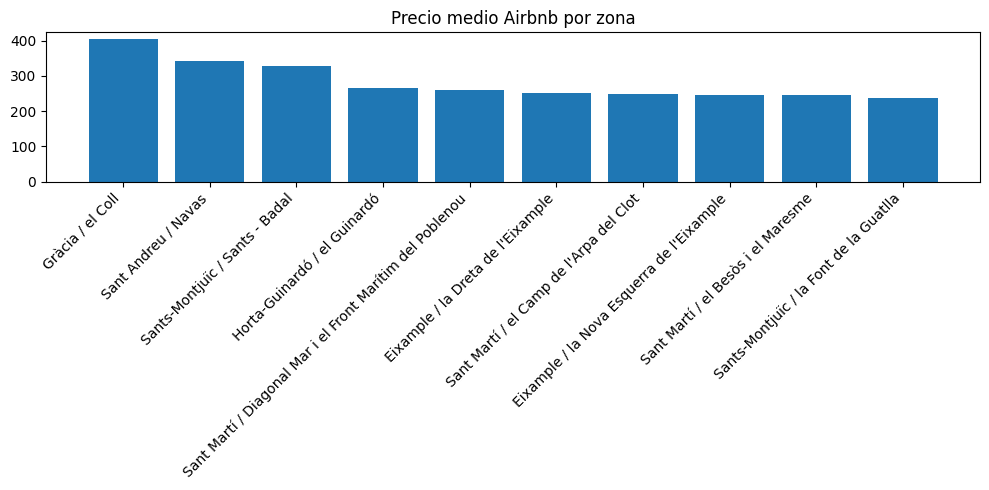

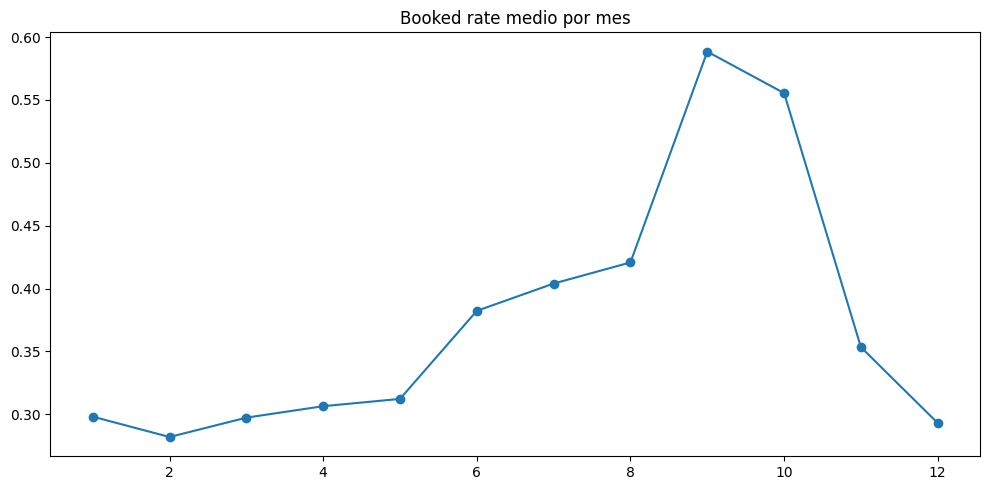

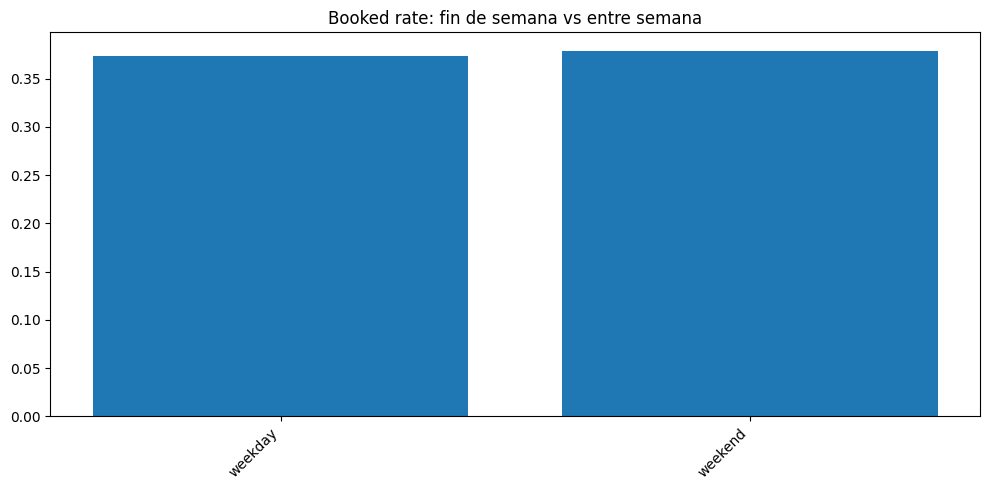

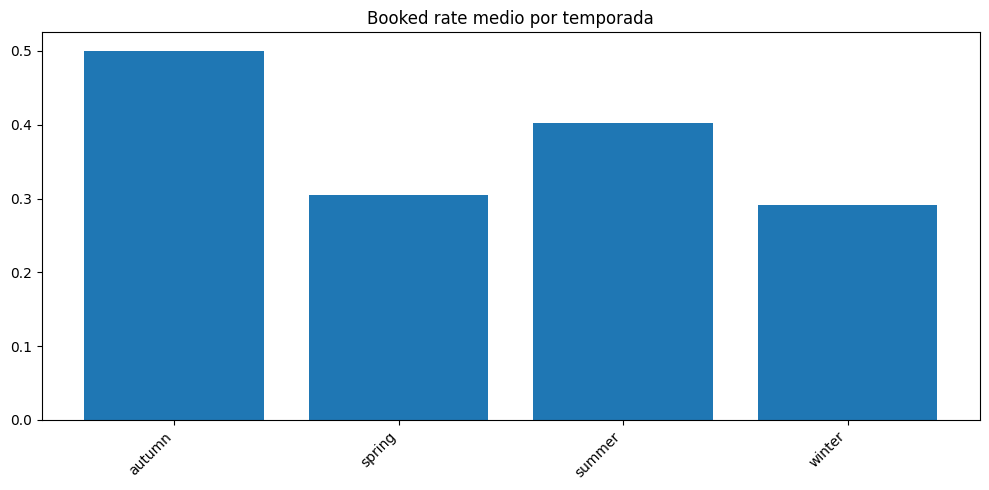

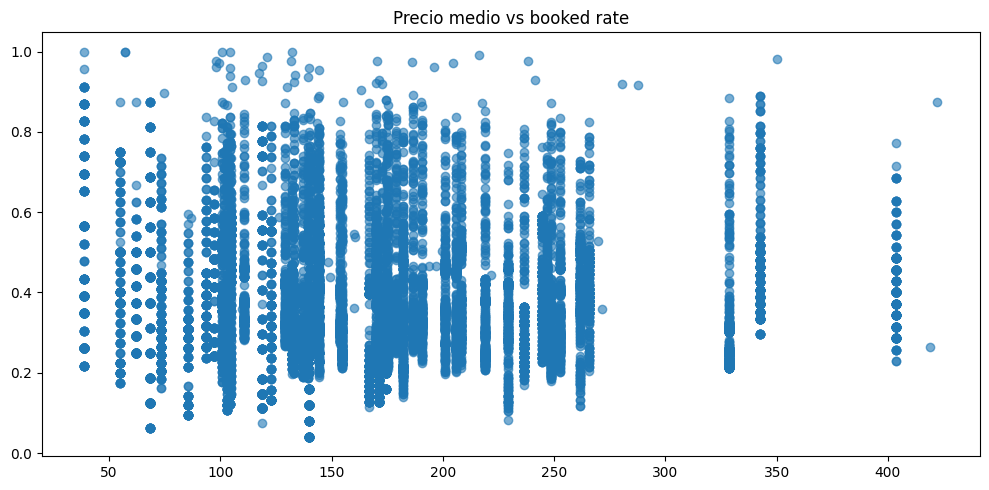

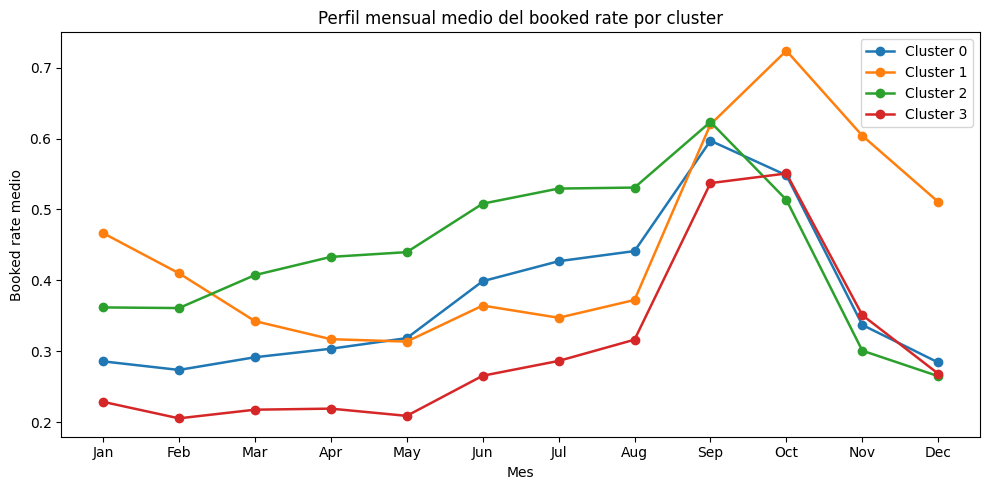

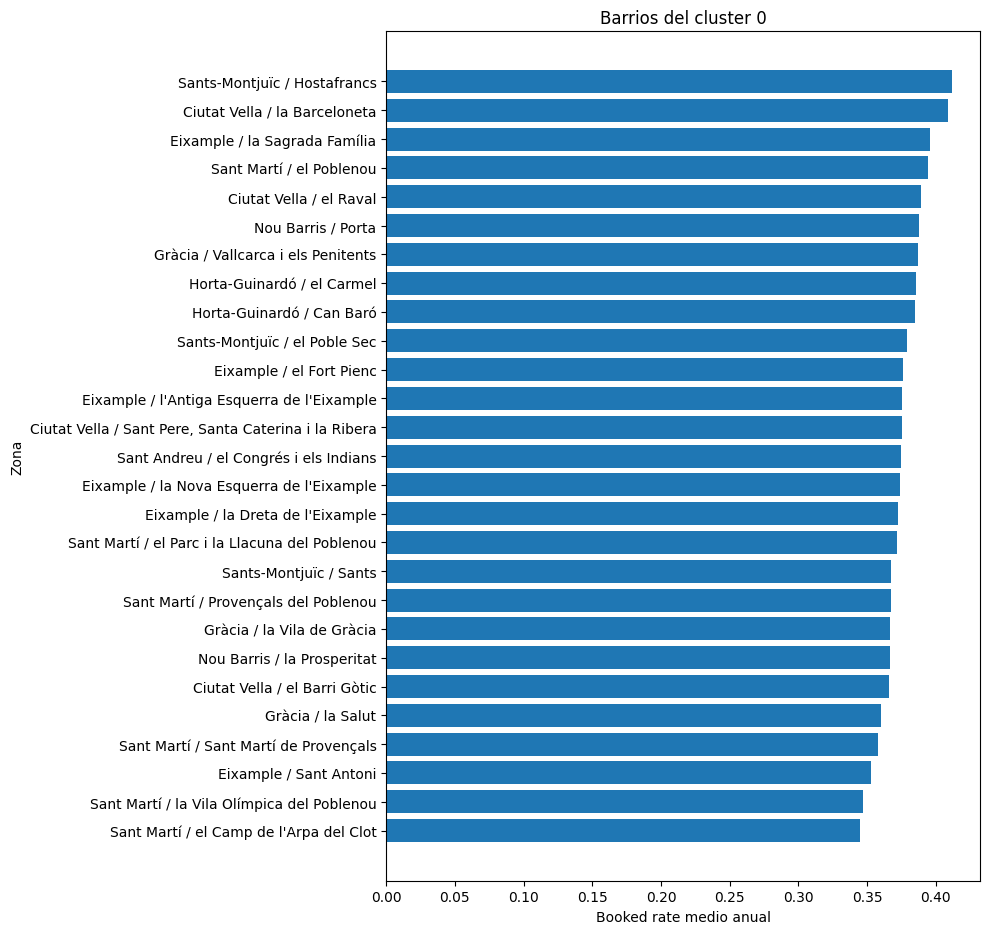

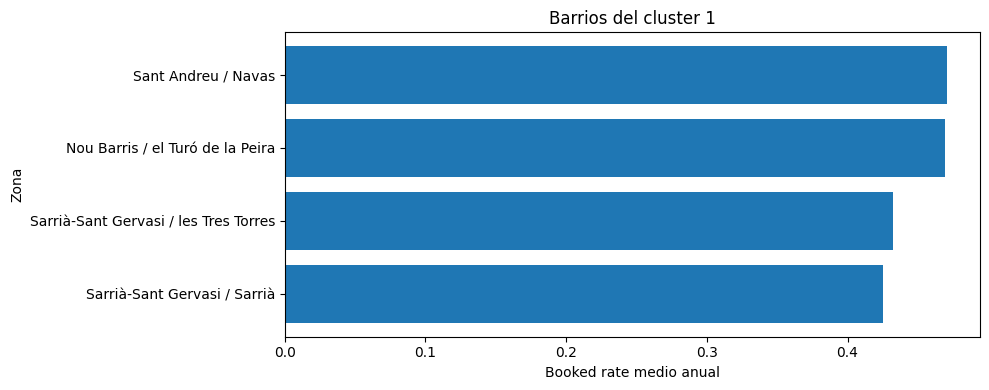

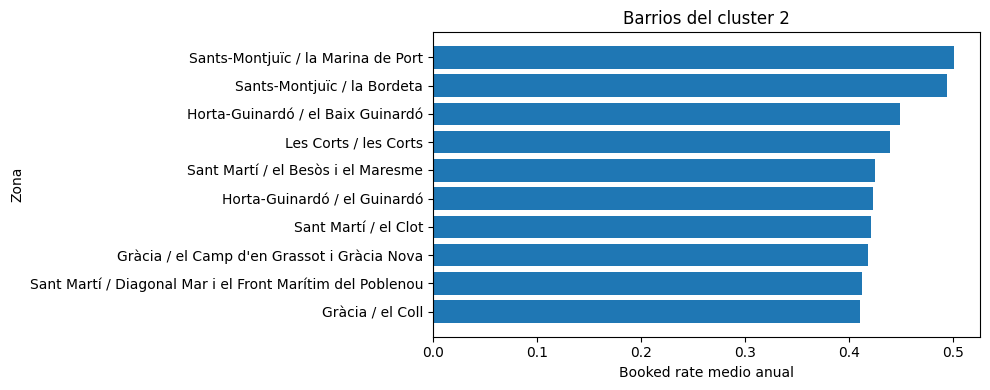

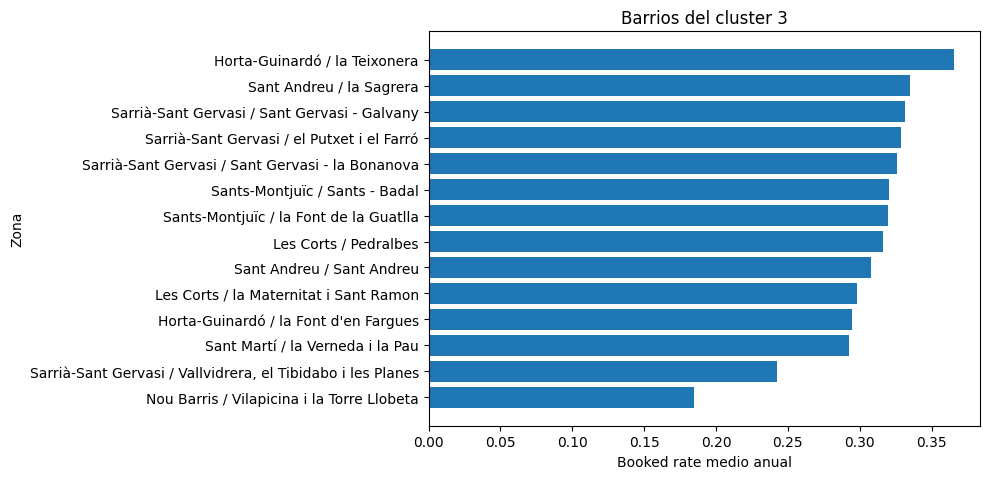

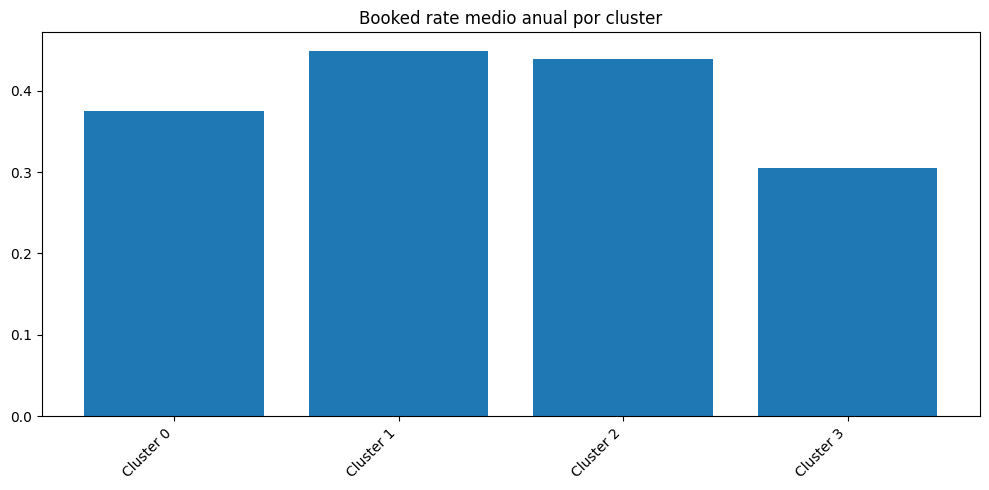

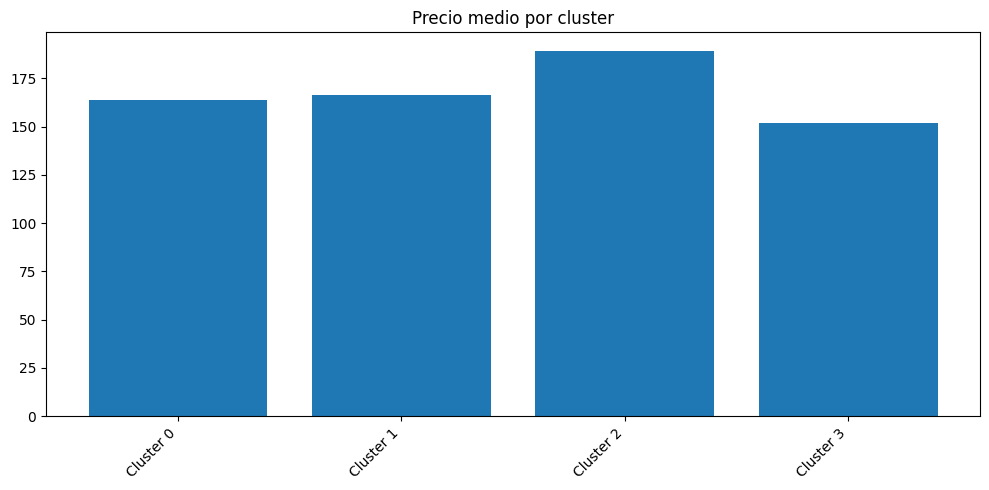

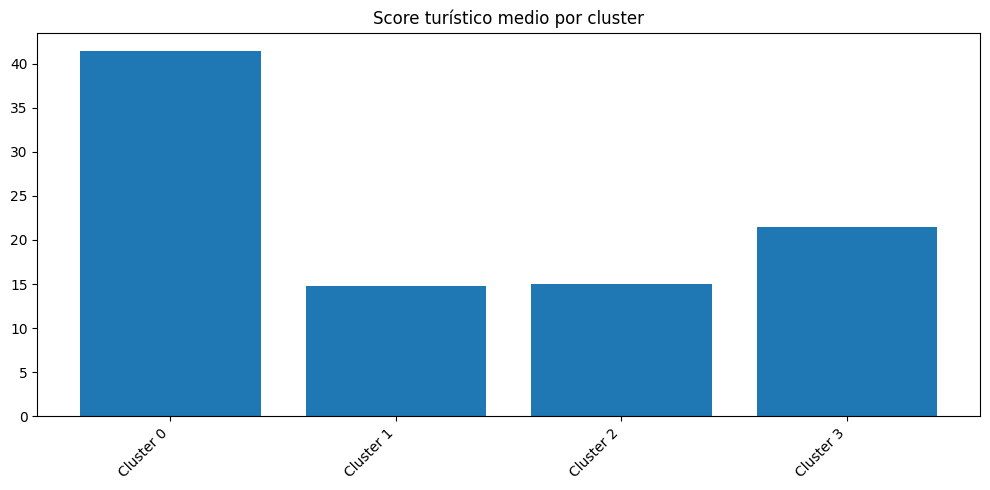

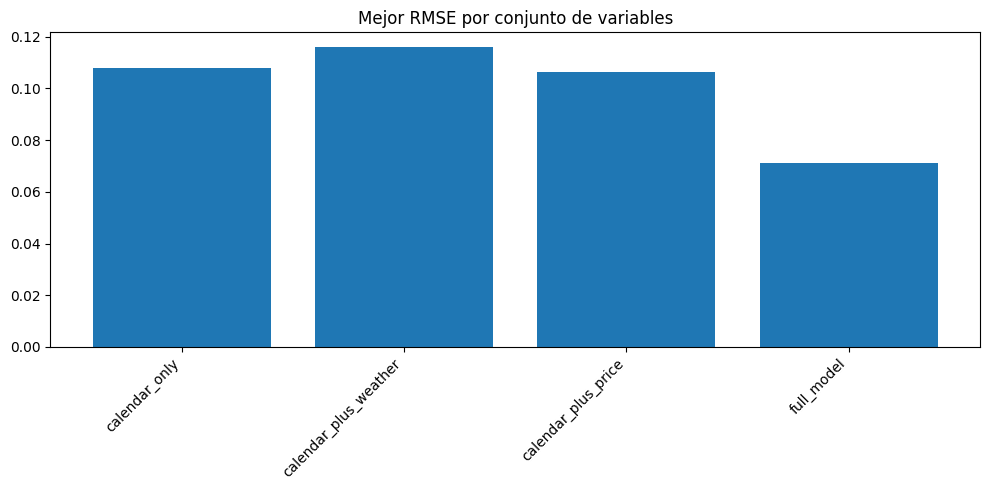

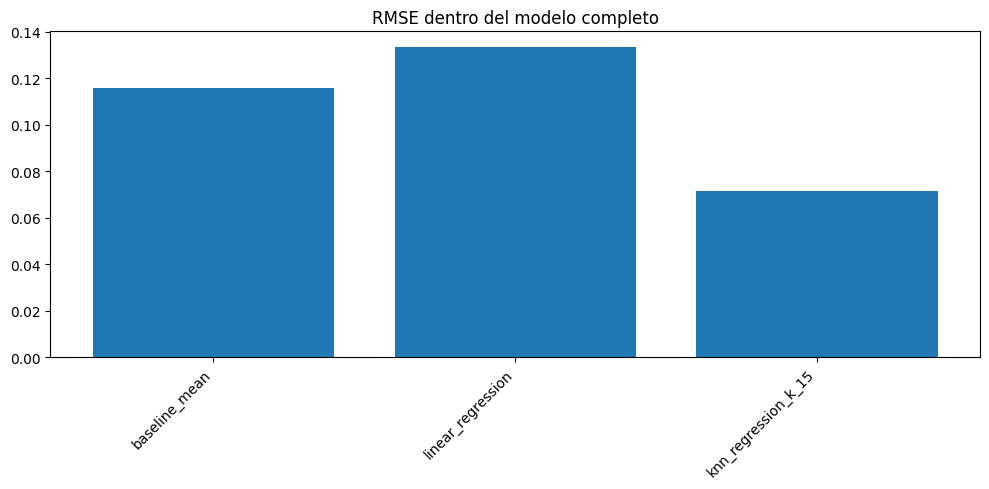

{'exploratory': {'source_tables': ['airbnb_zone_features',
   'airbnb_zone_day_features'],
  'top_price_zones': [{'district_name': 'Gràcia',
    'neighborhood_name': 'el Coll',
    'listing_count': 35,
    'avg_price': 403.4286,
    'neighborhood_tourism_asset_score': 9},
   {'district_name': 'Sant Andreu',
    'neighborhood_name': 'Navas',
    'listing_count': 54,
    'avg_price': 342.463,
    'neighborhood_tourism_asset_score': 2},
   {'district_name': 'Sants-Montjuïc',
    'neighborhood_name': 'Sants - Badal',
    'listing_count': 156,
    'avg_price': 328.4615,
    'neighborhood_tourism_asset_score': 4},
   {'district_name': 'Horta-Guinardó',
    'neighborhood_name': 'el Guinardó',
    'listing_count': 103,
    'avg_price': 265.6408,
    'neighborhood_tourism_asset_score': 13},
   {'district_name': 'Sant Martí',
    'neighborhood_name': 'Diagonal Mar i el Front Marítim del Poblenou',
    'listing_count': 128,
    'avg_price': 261.5156,
    'neighborhood_tourism_asset_score': 31},
 

In [12]:
ensure_phase_dirs()
analysis_results = {
    "exploratory": run_exploratory_pipeline(),
    "temporal_clustering": run_temporal_clustering_pipeline(),
    "prediction": run_prediction_pipeline(),
    "exploitation_database": {"path": str(EXPLOITATION_DB)},
}
analysis_results
